IRIS FLOWER DATASET

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes:
['setosa' 'versicolor' 'virginica']

Total number of samples: 150

Training samples: 120
Testing samples: 30

CLASSIFICATION ALGORITHM PERFORMANCE

Algorithm: Logistic Regression
Accuracy : 93.33 %
Precision: 93.33 %
Recall   : 93.33 %
F1-Score : 93.33 %

Algorithm: K-Nearest Neighbors
Accuracy : 93.33 %
Precision: 94.44 %
Recall   : 93.33 %
F1-Score : 93.27 %

Algorithm: Decision Tree
Accuracy : 93.33 %
Precision: 93.33 %
Recall   : 93.33 %
F1-Score : 93.33 %

Algorithm: Naive Bayes
Accuracy : 96.67 %
Precision: 96.97 %
Recall   : 96.67 %
F1-Score : 96.66 %

Algorithm: Support Vector Machine
Accuracy : 96.67 %
Precision: 96.97 %
Recall   : 96.67 %
F1-Score : 96.66 %

Algorithm: Random Forest
Accuracy : 90.0 %
Precision: 90.24 %
Recall   : 90.0 %
F1-Score : 89.97 %

ALGORITHM PERFORMANCE COMPARISON

Algorithm                 Accuracy     Precision    Recall       

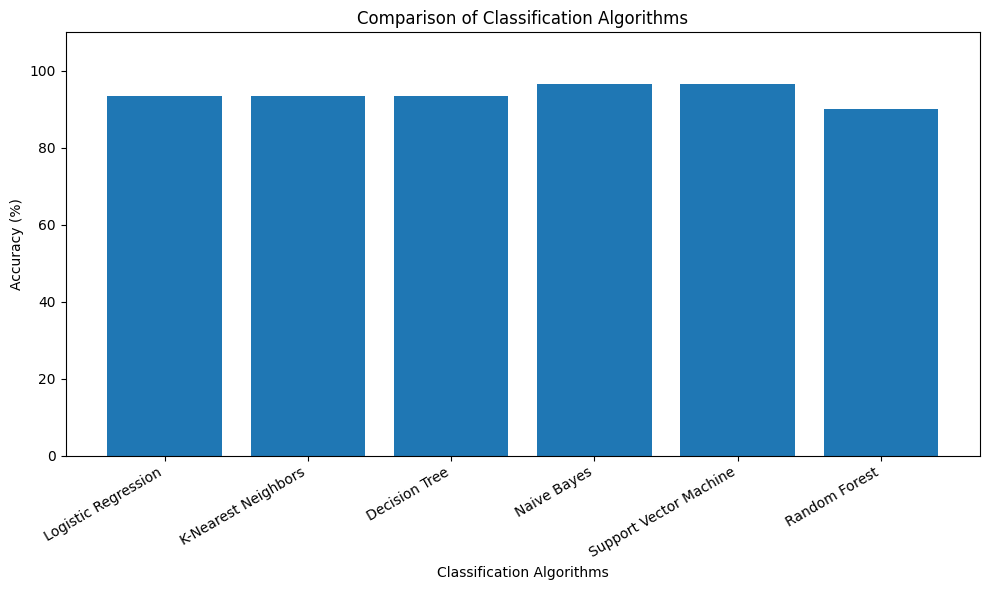

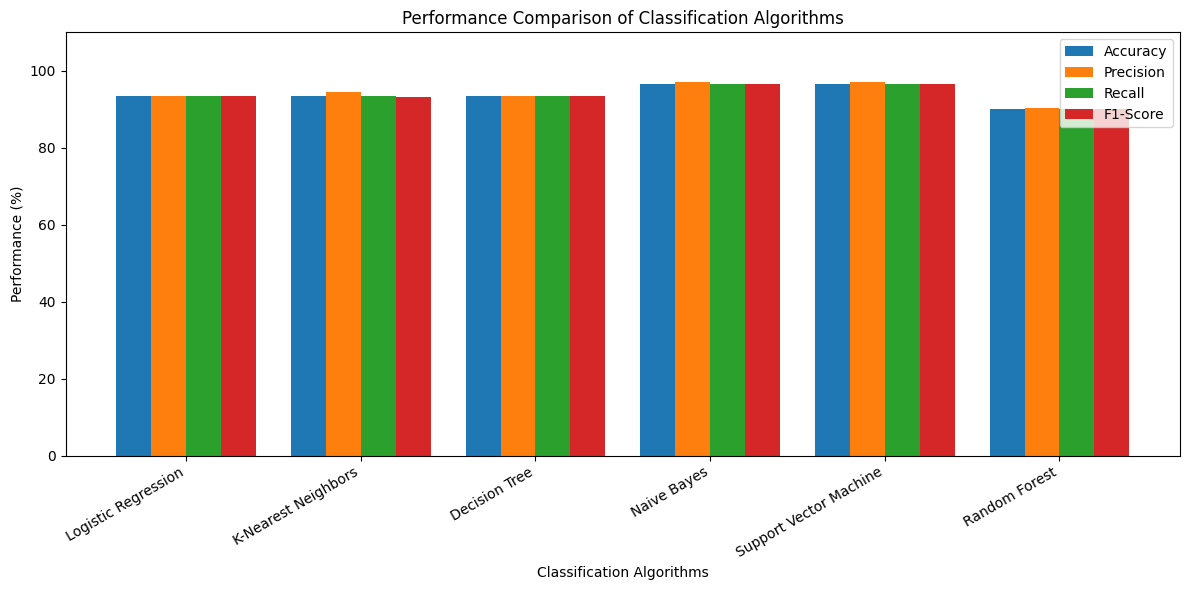


--------------------------------------------------
Confusion Matrix - Logistic Regression
--------------------------------------------------
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


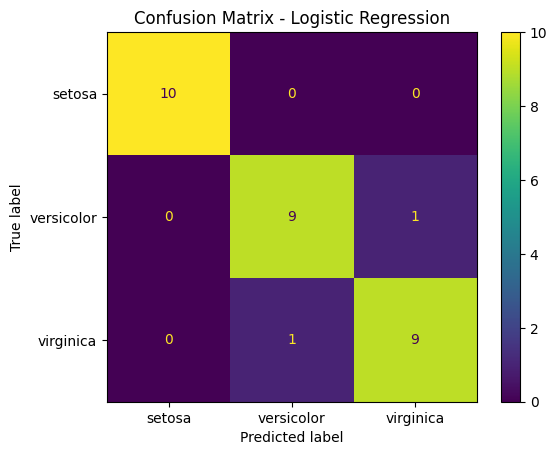


--------------------------------------------------
Confusion Matrix - K-Nearest Neighbors
--------------------------------------------------
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


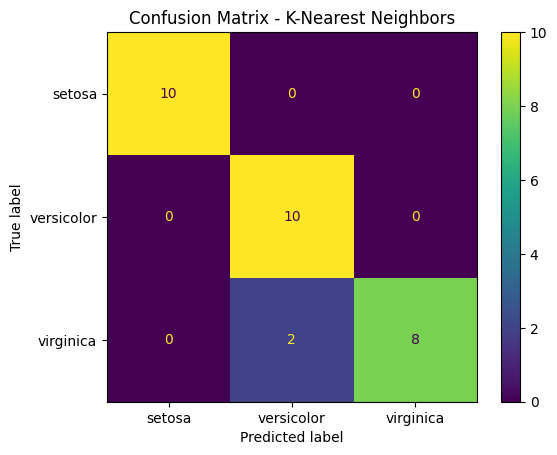


--------------------------------------------------
Confusion Matrix - Decision Tree
--------------------------------------------------
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


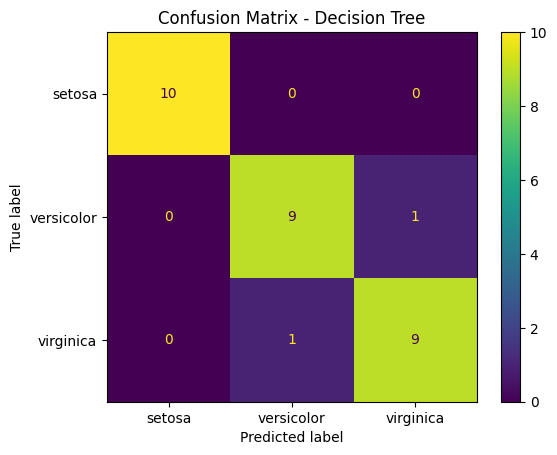


--------------------------------------------------
Confusion Matrix - Naive Bayes
--------------------------------------------------
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


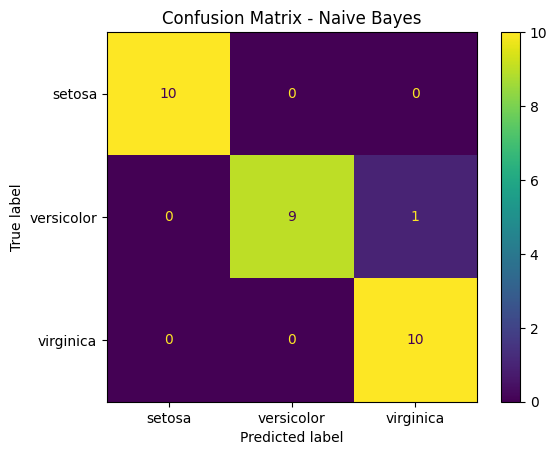


--------------------------------------------------
Confusion Matrix - Support Vector Machine
--------------------------------------------------
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


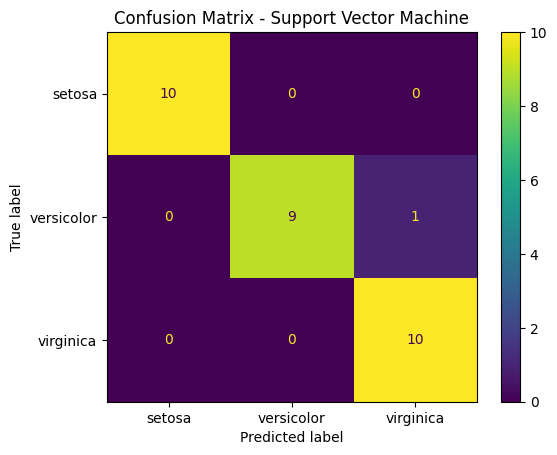


--------------------------------------------------
Confusion Matrix - Random Forest
--------------------------------------------------
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


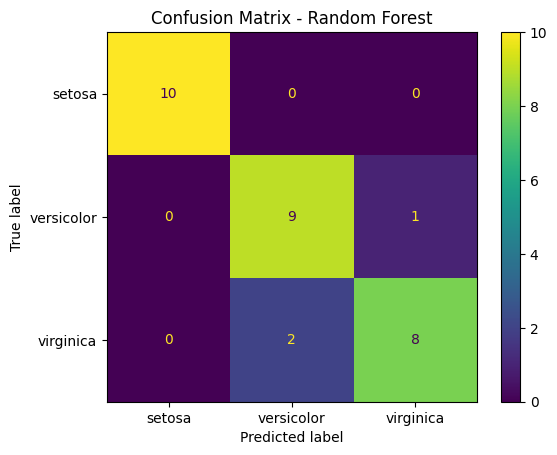


NEW FLOWER CLASSIFICATION

New Flower Details:
Sepal Length: 5.1 cm
Sepal Width : 3.5 cm
Petal Length: 1.4 cm
Petal Width : 0.2 cm

Best Algorithm: Naive Bayes
Predicted Flower Class: setosa


In [ ]:
# Experiment: Comparison of Classification Algorithms
# Aim: Compare different classification algorithms and
#      evaluate their performance.

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ---------------------------------------------------------
# STEP 1: Load the Iris dataset
# ---------------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

print("IRIS FLOWER DATASET")
print("=" * 60)

print("\nFeatures:")
print(iris.feature_names)

print("\nClasses:")
print(iris.target_names)

print("\nTotal number of samples:", len(X))


# ---------------------------------------------------------
# STEP 2: Split dataset into training and testing data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 3: Feature Scaling
# ---------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ---------------------------------------------------------
# STEP 4: Create classification models
# ---------------------------------------------------------

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=200),

    "K-Nearest Neighbors":
        KNeighborsClassifier(n_neighbors=5),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Naive Bayes":
        GaussianNB(),

    "Support Vector Machine":
        SVC(),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
}


# ---------------------------------------------------------
# STEP 5: Train and evaluate each model
# ---------------------------------------------------------

results = {}

print("\n" + "=" * 60)
print("CLASSIFICATION ALGORITHM PERFORMANCE")
print("=" * 60)

for name, model in models.items():

    # Use scaled data for Logistic Regression, KNN and SVM
    if name in [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Support Vector Machine"
    ]:

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)


    # Calculate performance metrics

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )


    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }


    print("\nAlgorithm:", name)

    print("Accuracy :", round(accuracy * 100, 2), "%")
    print("Precision:", round(precision * 100, 2), "%")
    print("Recall   :", round(recall * 100, 2), "%")
    print("F1-Score :", round(f1 * 100, 2), "%")


# ---------------------------------------------------------
# STEP 6: Display comparison table
# ---------------------------------------------------------

print("\n" + "=" * 80)
print("ALGORITHM PERFORMANCE COMPARISON")
print("=" * 80)

print(
    "\n{:<25} {:<12} {:<12} {:<12} {:<12}".format(
        "Algorithm",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    )
)

print("-" * 80)

for name, metrics in results.items():

    print(
        "{:<25} {:<12.2f} {:<12.2f} {:<12.2f} {:<12.2f}".format(
            name,
            metrics["Accuracy"] * 100,
            metrics["Precision"] * 100,
            metrics["Recall"] * 100,
            metrics["F1-Score"] * 100
        )
    )


# ---------------------------------------------------------
# STEP 7: Find the best performing algorithm
# ---------------------------------------------------------

best_algorithm = max(
    results,
    key=lambda x: results[x]["Accuracy"]
)

best_accuracy = results[best_algorithm]["Accuracy"]

print("\n" + "=" * 60)
print("BEST PERFORMING ALGORITHM")
print("=" * 60)

print("\nAlgorithm:", best_algorithm)
print("Accuracy:", round(best_accuracy * 100, 2), "%")


# ---------------------------------------------------------
# STEP 8: Plot accuracy comparison
# ---------------------------------------------------------

algorithm_names = list(results.keys())

accuracy_values = [
    results[name]["Accuracy"] * 100
    for name in algorithm_names
]

plt.figure(figsize=(10, 6))

plt.bar(
    algorithm_names,
    accuracy_values
)

plt.xlabel("Classification Algorithms")
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Classification Algorithms")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.ylim(0, 110)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# STEP 9: Plot all performance metrics
# ---------------------------------------------------------

precision_values = [
    results[name]["Precision"] * 100
    for name in algorithm_names
]

recall_values = [
    results[name]["Recall"] * 100
    for name in algorithm_names
]

f1_values = [
    results[name]["F1-Score"] * 100
    for name in algorithm_names
]

x = np.arange(len(algorithm_names))

width = 0.2

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    accuracy_values,
    width,
    label="Accuracy"
)

plt.bar(
    x,
    precision_values,
    width,
    label="Precision"
)

plt.bar(
    x + width,
    recall_values,
    width,
    label="Recall"
)

plt.bar(
    x + 2 * width,
    f1_values,
    width,
    label="F1-Score"
)

plt.xlabel("Classification Algorithms")
plt.ylabel("Performance (%)")
plt.title("Performance Comparison of Classification Algorithms")

plt.xticks(
    x + width / 2,
    algorithm_names,
    rotation=30,
    ha="right"
)

plt.ylim(0, 110)

plt.legend()

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# STEP 10: Generate confusion matrices
# ---------------------------------------------------------

for name, model in models.items():

    if name in [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Support Vector Machine"
    ]:

        y_pred = model.predict(X_test_scaled)

    else:

        y_pred = model.predict(X_test)


    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "-" * 50)
    print("Confusion Matrix -", name)
    print("-" * 50)

    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=iris.target_names
    )

    disp.plot()

    plt.title(
        "Confusion Matrix - " + name
    )

    plt.show()


# ---------------------------------------------------------
# STEP 11: Predict a new flower using the best algorithm
# ---------------------------------------------------------

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])


# Train/predict using the best algorithm

best_model = models[best_algorithm]


if best_algorithm in [
    "Logistic Regression",
    "K-Nearest Neighbors",
    "Support Vector Machine"
]:

    new_flower_scaled = scaler.transform(new_flower)

    prediction = best_model.predict(
        new_flower_scaled
    )

else:

    prediction = best_model.predict(
        new_flower
    )


print("\n" + "=" * 60)
print("NEW FLOWER CLASSIFICATION")
print("=" * 60)

print("\nNew Flower Details:")

print("Sepal Length: 5.1 cm")
print("Sepal Width : 3.5 cm")
print("Petal Length: 1.4 cm")
print("Petal Width : 0.2 cm")

print("\nBest Algorithm:", best_algorithm)

print(
    "Predicted Flower Class:",
    iris.target_names[prediction[0]]
)